# Bank Marketing — ML, XAI & Data Viz Lab

**Dataset:** [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
**Goal:** Predict whether a client will subscribe to a term deposit (`y = yes/no`).

---

## Lab Structure

| Section | Topic | Status |
|---------|-------|--------|
| 1 | Setup & Data Loading | Provided |
| 2 | Exploratory Data Analysis (EDA) | Partial — extend it |
| 3 | Preprocessing | Provided |
| 4 | Modeling | Partial — extend it |
| 5 | Evaluation & Viz | Partial — extend it |
| 6 | XAI with SHAP | Partial — extend it |
| 7 | XAI with LIME | Partial — extend it |
| 8 | Extensions | You implement this |

> **Convention:**  
> - `# PROVIDED` — working code, read and understand it  
> - `# TODO` — you must write this  
> - `# HINT` — nudge in the right direction

## Section 1 — Setup & Data Loading

In [91]:
# PROVIDED — install dependencies (run once)
# !pip install -r requirements.txt

In [92]:
# PROVIDED — imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    make_scorer, f1_score
)
import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


In [93]:
# PROVIDED — load dataset via ucimlrepo
bank = fetch_ucirepo(id=222)

X_raw = bank.data.features.copy()
y_raw = bank.data.targets.copy()

print('Features shape:', X_raw.shape)
print('Target shape  :', y_raw.shape)
X_raw.head()

Features shape: (45211, 16)
Target shape  : (45211, 1)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


### 1.1 — Dataset Dictionary

| Feature | Type | Description |
|---------|------|-------------|
| `age` | numeric | Client age |
| `job` | categorical | Type of job |
| `marital` | categorical | Marital status |
| `education` | categorical | Education level |
| `default` | binary | Has credit in default? |
| `housing` | binary | Has housing loan? |
| `loan` | binary | Has personal loan? |
| `contact` | categorical | Contact type (cellular/telephone) |
| `month` | categorical | Last contact month |
| `day_of_week` | categorical | Last contact day |
| `duration` | numeric | Last contact duration (seconds) |
| `campaign` | numeric | # contacts this campaign |
| `pdays` | numeric | Days since last contact (999 = never) |
| `previous` | numeric | # contacts before this campaign |
| `poutcome` | categorical | Previous campaign outcome |
| `emp.var.rate` | numeric | Employment variation rate |
| `cons.price.idx` | numeric | Consumer price index |
| `cons.conf.idx` | numeric | Consumer confidence index |
| `euribor3m` | numeric | Euribor 3-month rate |
| `nr.employed` | numeric | Number of employees (economy) |
| **`y`** | **binary** | **Subscribed? (target)** |

---
## Section 2 — Exploratory Data Analysis (EDA)

In [94]:
# PROVIDED — basic info
print('=== dtypes ===')
print(X_raw.dtypes)
print('\n=== missing values ===')
print(X_raw.isnull().sum())
print('\n=== describe (numeric) ===')
X_raw.describe()

=== dtypes ===
age            int64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day_of_week    int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
dtype: object

=== missing values ===
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

=== describe (numeric) ===


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


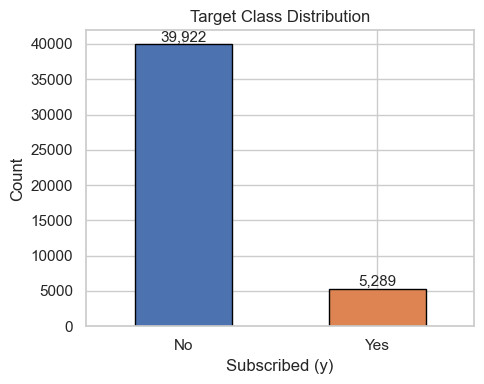

Class imbalance ratio: 7.5:1


In [95]:
# PROVIDED — target class distribution
target_counts = y_raw['y'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Class imbalance ratio: {target_counts.iloc[0] / target_counts.iloc[1]:.1f}:1')

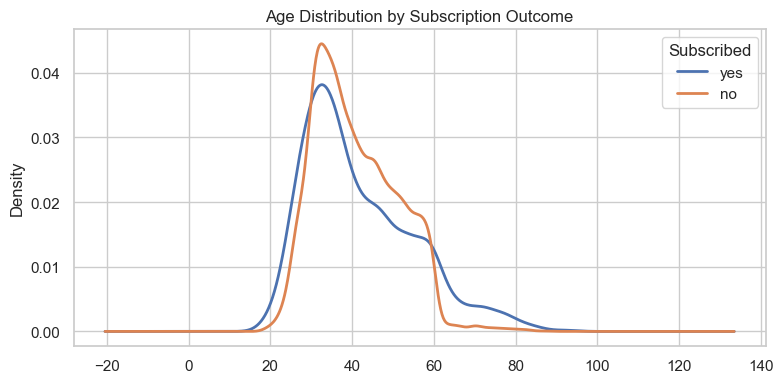

In [96]:
# PROVIDED — age distribution split by target
df_eda = X_raw.copy()
df_eda['y'] = y_raw['y'].values

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [('yes', '#4C72B0'), ('no', '#DD8452')]:
    df_eda[df_eda['y'] == label]['age'].plot(
        kind='kde', ax=ax, label=label, color=color, linewidth=2
    )
ax.set_title('Age Distribution by Subscription Outcome')
ax.legend(title='Subscribed')
plt.tight_layout()
plt.show()

In [97]:
# TODO 2.1 — Plot the subscription rate (%) by job category.
# Use a horizontal bar chart, sorted from highest to lowest rate.
# HINT: use groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100)

# YOUR CODE HERE

In [98]:
# TODO 2.2 — Plot a correlation heatmap for the NUMERIC features only.
# HINT: use df_eda.select_dtypes(include='number').corr() and sns.heatmap()

# YOUR CODE HERE

In [99]:
# TODO 2.3 — Investigate the 'duration' feature.
# Plot its distribution for subscribed vs not-subscribed clients.
# Then answer the question below about why it may be problematic.

# YOUR CODE HERE

**Your answer for 2.3 — why is `duration` problematic?**

> *Write your explanation here.*

---
## Section 3 — Preprocessing

In [100]:
# PROVIDED — encode categoricals and binary target
df = X_raw.copy()
y = (y_raw['y'] == 'yes').astype(int)   # 1 = subscribed, 0 = not

cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

feature_names = df.columns.tolist()

print('Categorical columns encoded:', cat_cols)
print('Final feature matrix shape :', df.shape)

Categorical columns encoded: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Final feature matrix shape : (45211, 16)


In [101]:
# PROVIDED — train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Positive rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

Train: 36168 samples | Test: 9043 samples
Positive rate — Train: 11.70% | Test: 11.70%


---
## Section 4 — Modeling

The baseline is a Random Forest. Your job is to understand it, benchmark it
against simpler models, and validate it properly.

> **Note:** `rf` is the model used in Sections 5-7. Keep it as your final
> chosen model, or swap it with your best model once you have compared them.

In [102]:
# PROVIDED — train a baseline Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',   # handles class imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Compute predictions here so they are available for all subsequent sections
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
print('Model trained')

Model trained


### 4.1 — Baseline Comparison

A good ML workflow always benchmarks against simpler models.
Train a Logistic Regression and compare it to the Random Forest.

In [103]:
# TODO 4.1 — Train a Logistic Regression and print its classification report.
# Scale the features first with StandardScaler, then fit LogisticRegression separately.
# Build a small comparison table (AUC-ROC, F1 for class=1) for LR vs RF.
#
# HINT: scaler = StandardScaler()
#       X_train_scaled = scaler.fit_transform(X_train)
#       X_test_scaled  = scaler.transform(X_test)
# HINT: class_weight='balanced' is available here too

# YOUR CODE HERE

### 4.2 — Decision Threshold Tuning

By default sklearn uses a threshold of **0.5** to convert probabilities to
class labels. For imbalanced datasets, a lower threshold often improves recall
on the minority class. The Precision-Recall curve helps you pick the right
trade-off.

In [104]:
# TODO 4.2 — Plot the Precision-Recall curve for the Random Forest.
# Identify the threshold that maximises F1 for class=1, then:
#   (a) print the classification report at that threshold
#   (b) compare recall and precision vs the default threshold=0.5
#
# HINT: precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
# HINT: f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
# HINT: best_threshold = thresholds[np.argmax(f1_scores[:-1])]
# HINT: y_pred_tuned = (y_prob >= best_threshold).astype(int)

# YOUR CODE HERE

### Bonus — Cross-Validation

A single train/test split can give optimistic or pessimistic results depending
on the random seed. Stratified K-Fold cross-validation gives a more robust
estimate. The code below is provided — run it and observe how consistent the
scores are across folds.

In [105]:
# PROVIDED (Bonus) — 5-fold stratified cross-validation on the Random Forest
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'roc_auc':     'roc_auc',
    'f1_weighted': 'f1_weighted',
    'f1_class1':   make_scorer(f1_score, pos_label=1),
}
cv_results = cross_validate(rf, df, y, cv=cv, scoring=scoring)

print('Cross-Validation Results (5-fold):')
for label, key in [('AUC-ROC    ', 'test_roc_auc'),
                   ('F1 weighted', 'test_f1_weighted'),
                   ('F1 class=1 ', 'test_f1_class1')]:
    scores = cv_results[key]
    print(f'  {label}: {scores.mean():.3f} +/- {scores.std():.3f}')

Cross-Validation Results (5-fold):
  AUC-ROC    : 0.917 +/- 0.003
  F1 weighted: 0.869 +/- 0.003
  F1 class=1 : 0.564 +/- 0.008


---
## Section 5 — Evaluation & Visualization

In [106]:
# PROVIDED — classification report
# (y_pred and y_prob were computed right after training in Section 4)
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.97      0.85      0.91      7985
         Yes       0.42      0.83      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.84      0.74      9043
weighted avg       0.91      0.85      0.87      9043



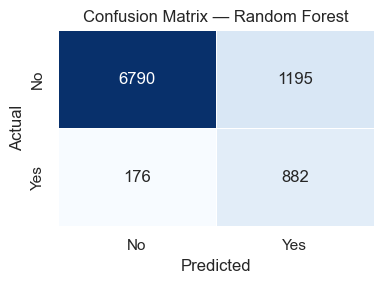

In [107]:
# PROVIDED — confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
    linewidths=0.5, cbar=False, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

### 5.1 — Interpret the Results

Before plotting anything, take a moment to critically read the numbers above.

**TODO 5.1 — Answer the following questions based on the classification report and confusion matrix.**

---

**Q1 — Is accuracy a good metric here? Why or why not?**  
*Hint: what would a model that always predicts "No" achieve in accuracy? Compare that with the report.*

> *Your answer here.*

---

**Q2 — The model has very different precision and recall for class "Yes". Which one is more important for a marketing campaign? Justify your choice.**  
*Hint: think about the cost of a false negative (missing a potential subscriber) vs a false positive (calling someone who will not subscribe).*

> *Your answer here.*

---

**Q3 — Look at the F1-score for class "Yes". Is it satisfactory? What does it tell you about the model's ability to identify subscribers?**  
*Hint: F1 is the harmonic mean of precision and recall — it is only high when both are high.*

> *Your answer here.*

---

**Q4 — Compare the results of Logistic Regression vs Random Forest (from Section 4). Which model would you choose and why?**  
*Hint: consider not just overall accuracy but precision/recall trade-offs for the minority class.*

> *Your answer here.*

In [108]:
# TODO 5.2 — Plot the ROC curve and annotate it with the AUC score.
# HINT: use roc_curve() and roc_auc_score() from sklearn.metrics

# YOUR CODE HERE

In [109]:
# TODO 5.3 — Plot the top-15 feature importances (rf.feature_importances_)
# as a horizontal bar chart. Which features matter most?

# YOUR CODE HERE

---
## Section 6 — XAI with SHAP

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value
to a specific prediction, based on game theory.

- Positive SHAP value: pushes prediction towards class 1 (subscribed)
- Negative SHAP value: pushes prediction away from class 1

We compute two levels:

- **Global** explanations — which features matter overall?
- **Local** explanations — why did the model predict this specific client?

In [110]:
# PROVIDED — compute SHAP values (TreeExplainer is fast for Random Forest)
explainer_shap = shap.TreeExplainer(rf)

# Use a sample for speed (full test set can be slow)
X_shap = X_test.sample(500, random_state=RANDOM_STATE)
shap_values_raw = explainer_shap.shap_values(X_shap)

# Normalise: newer SHAP returns a 3-D array (samples, features, classes);
# older versions return a list [class_0_array, class_1_array].
if isinstance(shap_values_raw, list):
    sv = shap_values_raw[1]              # old API — class 1
else:
    sv = shap_values_raw[:, :, 1]        # new API — class 1

ev = (explainer_shap.expected_value[1]
      if hasattr(explainer_shap.expected_value, '__len__')
      else explainer_shap.expected_value)

print('SHAP values shape:', sv.shape)

SHAP values shape: (500, 16)


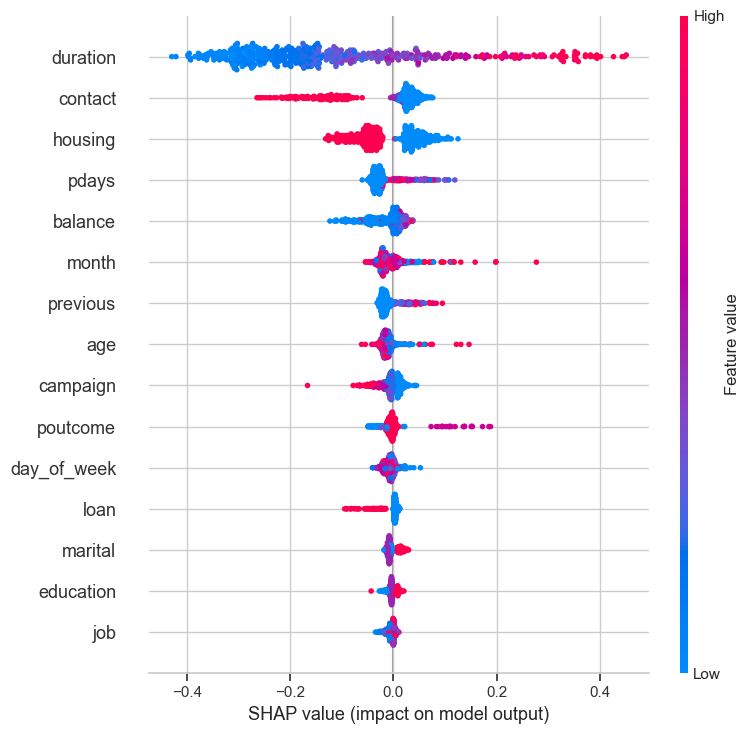

In [111]:
# PROVIDED — global SHAP summary plot (beeswarm)
shap.summary_plot(
    sv, X_shap,
    feature_names=feature_names,
    plot_type='dot',
    max_display=15
)

Predicted probability of subscribing: 93.49%


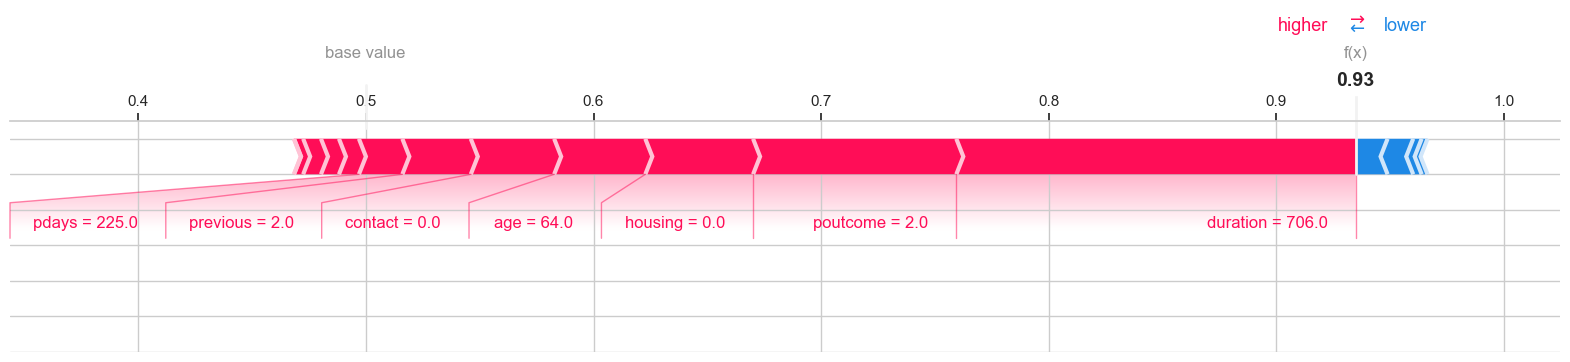

In [112]:
# PROVIDED — local SHAP explanation for a single correctly predicted positive
sample_idx = y_test[y_test == 1].index[0]
sample_pos = X_test.loc[[sample_idx]]
shap_single_raw = explainer_shap.shap_values(sample_pos)

if isinstance(shap_single_raw, list):
    sv_single = shap_single_raw[1][0]
else:
    sv_single = shap_single_raw[0, :, 1]

print(f'Predicted probability of subscribing: {rf.predict_proba(sample_pos)[0, 1]:.2%}')
shap.force_plot(
    ev,
    sv_single,
    sample_pos.iloc[0],
    feature_names=feature_names,
    matplotlib=True
)

In [113]:
# TODO 6.1 — Generate a SHAP bar plot (mean |SHAP|) for the top-10 features.
# HINT: shap.summary_plot(sv, X_shap, feature_names=feature_names, plot_type='bar', max_display=10)

# YOUR CODE HERE

In [114]:
# TODO 6.2 — Pick a FALSE NEGATIVE (model predicted 0, actual is 1).
# Generate a SHAP force plot for it and explain in the markdown cell below
# what features are pushing the model towards the wrong prediction.
#
# HINT: false_negatives = X_test[(y_test == 1) & (rf.predict(X_test) == 0)]
# HINT: use sv and ev defined in the cell above, or recompute shap_values for
#       the selected instance following the same normalisation pattern.

# YOUR CODE HERE

**Your answer for 6.2 — what features caused the false negative?**

> *Write your explanation here.*

---
## Section 7 — XAI with LIME

LIME (Local Interpretable Model-agnostic Explanations) builds a local linear
approximation around a single prediction. It perturbs the input, observes how
the model responds, and fits a simple model to explain that neighbourhood.

Key difference from SHAP: LIME is fully model-agnostic and focuses only on
local explanations.

In [115]:
# PROVIDED — create LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    mode='classification',
    random_state=RANDOM_STATE
)
print('LIME explainer ready')

LIME explainer ready


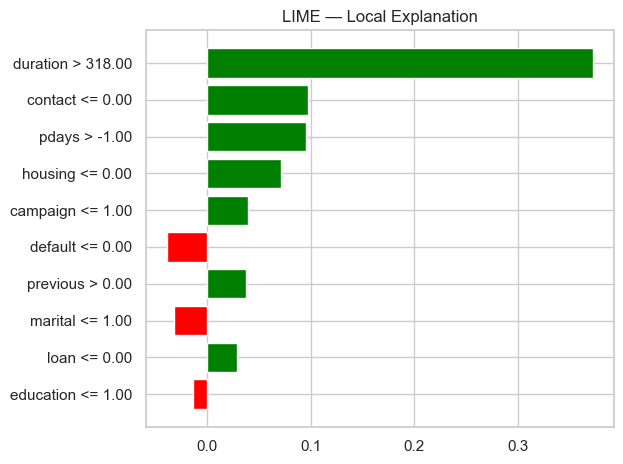

In [116]:
# PROVIDED — LIME explanation for a single instance (same as SHAP above)
instance = X_test.loc[sample_idx].values

lime_exp = explainer_lime.explain_instance(
    instance,
    rf.predict_proba,
    num_features=10,
    num_samples=1000
)

lime_exp.as_pyplot_figure()
plt.title('LIME — Local Explanation')
plt.tight_layout()
plt.show()

In [117]:
# TODO 7.1 — Pick a client the model predicts with HIGH confidence (prob > 0.85)
# and one with LOW confidence (0.45 < prob < 0.55).
# Run LIME on both and compare the explanations side-by-side.

# YOUR CODE HERE

In [118]:
# TODO 7.2 — Compare the top-5 features from SHAP (Section 6) vs LIME.
# Create a simple table or text summary. Do they agree? Where do they diverge?

# YOUR CODE HERE

**Your answer for 7.2 — SHAP vs LIME comparison**

> *Write your comparison here.*

---
## Section 8 — Extensions (choose at least 2)

---

### Extension A — Handle Class Imbalance

The dataset is imbalanced (~11% positive). Try one of:

- SMOTE oversampling (`from imblearn.over_sampling import SMOTE`)
- Adjusting the decision threshold using the Precision-Recall curve (see Section 4.2)

Measure the impact on recall for the minority class.

In [119]:
# TODO — Extension A

# YOUR CODE HERE

### Extension B — Drop `duration` and Retrain

The `duration` column causes data leakage: you only know the call length
after it happens. Remove it, retrain, and compare AUC and F1 against the
baseline.

In [120]:
# TODO — Extension B

# YOUR CODE HERE

### Extension C — Hyperparameter Tuning

Use `GridSearchCV` or `RandomizedSearchCV` to tune the Random Forest
(`n_estimators`, `max_depth`, `min_samples_split`). Report the best
parameters and the improvement in AUC-ROC.

In [121]:
# TODO — Extension C

# YOUR CODE HERE

### Extension D — SHAP Dependence Plot

A SHAP dependence plot shows how a single feature's value relates to its SHAP
contribution, coloured by an interaction feature. Use it to explore how
`euribor3m` or `nr.employed` interact with other features.

```python
shap.dependence_plot('euribor3m', shap_values[1], X_shap, feature_names=feature_names)
```

In [122]:
# TODO — Extension D

# YOUR CODE HERE

### Extension E — Business Insight Dashboard

Create a 4-panel matplotlib figure that tells a coherent story about which
customer segments to target in the next campaign. Combine model outputs and
SHAP values.

In [123]:
# TODO — Extension E

# YOUR CODE HERE

---
## Reflection Questions

Answer each in 2-4 sentences.

**Q1 — Why is accuracy a misleading metric for this dataset?**

> *Your answer here.*

**Q2 — What is the difference between a global and a local explanation? Give a concrete example from your results.**

> *Your answer here.*

**Q3 — Would you trust this model for a real marketing campaign? What would you change or validate further?**

> *Your answer here.*